# Day 23 - Feature Selection
60 Days Data Science | Phase: Feature Selection

**Date:** 05 June 2026  
**Name:** Rajesh Yadav


## Step 1 - Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, RFE, mutual_info_classif
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, classification_report
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

SEED = 42
np.random.seed(SEED)

print("numpy  :", np.__version__)
print("pandas :", pd.__version__)


numpy  : 2.2.1
pandas : 2.2.3


## Step 2 - Load and Preprocess Dataset

In [2]:
dataset_path = '../day15/telco_customer_churn.csv'
if not os.path.exists(dataset_path):
    dataset_path = 'telco_customer_churn.csv'

df_raw = pd.read_csv(dataset_path)
print(f"Raw shape: {df_raw.shape}")
print(df_raw.dtypes)

# basic cleaning
df = df_raw.copy()
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

# OHE all remaining object columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print(f"\nEncoded shape: {df_enc.shape}")
print("Null values:", df_enc.isnull().sum().sum())
df_enc.head(3)


Raw shape: (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Encoded shape: (7043, 31)
Null values: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1


## Step 3 - Correlation Heatmap

In [3]:
corr_matrix = df_enc.corr()

# top features correlated with Churn
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
top20_churn_corr = churn_corr.head(20)

print("Top 20 features by absolute correlation with Churn:")
print(top20_churn_corr.round(4).to_string())


Top 20 features by absolute correlation with Churn:
tenure                                 -0.3522
InternetService_Fiber optic             0.3080
Contract_Two year                      -0.3023
PaymentMethod_Electronic check          0.3019
InternetService_No                     -0.2279
OnlineSecurity_No internet service     -0.2279
DeviceProtection_No internet service   -0.2279
TechSupport_No internet service        -0.2279
StreamingMovies_No internet service    -0.2279
StreamingTV_No internet service        -0.2279
OnlineBackup_No internet service       -0.2279
TotalCharges                           -0.1983
MonthlyCharges                          0.1934
PaperlessBilling_Yes                    0.1918
Contract_One year                      -0.1778
OnlineSecurity_Yes                     -0.1712
TechSupport_Yes                        -0.1647
Dependents_Yes                         -0.1642
SeniorCitizen                           0.1509
Partner_Yes                            -0.1504


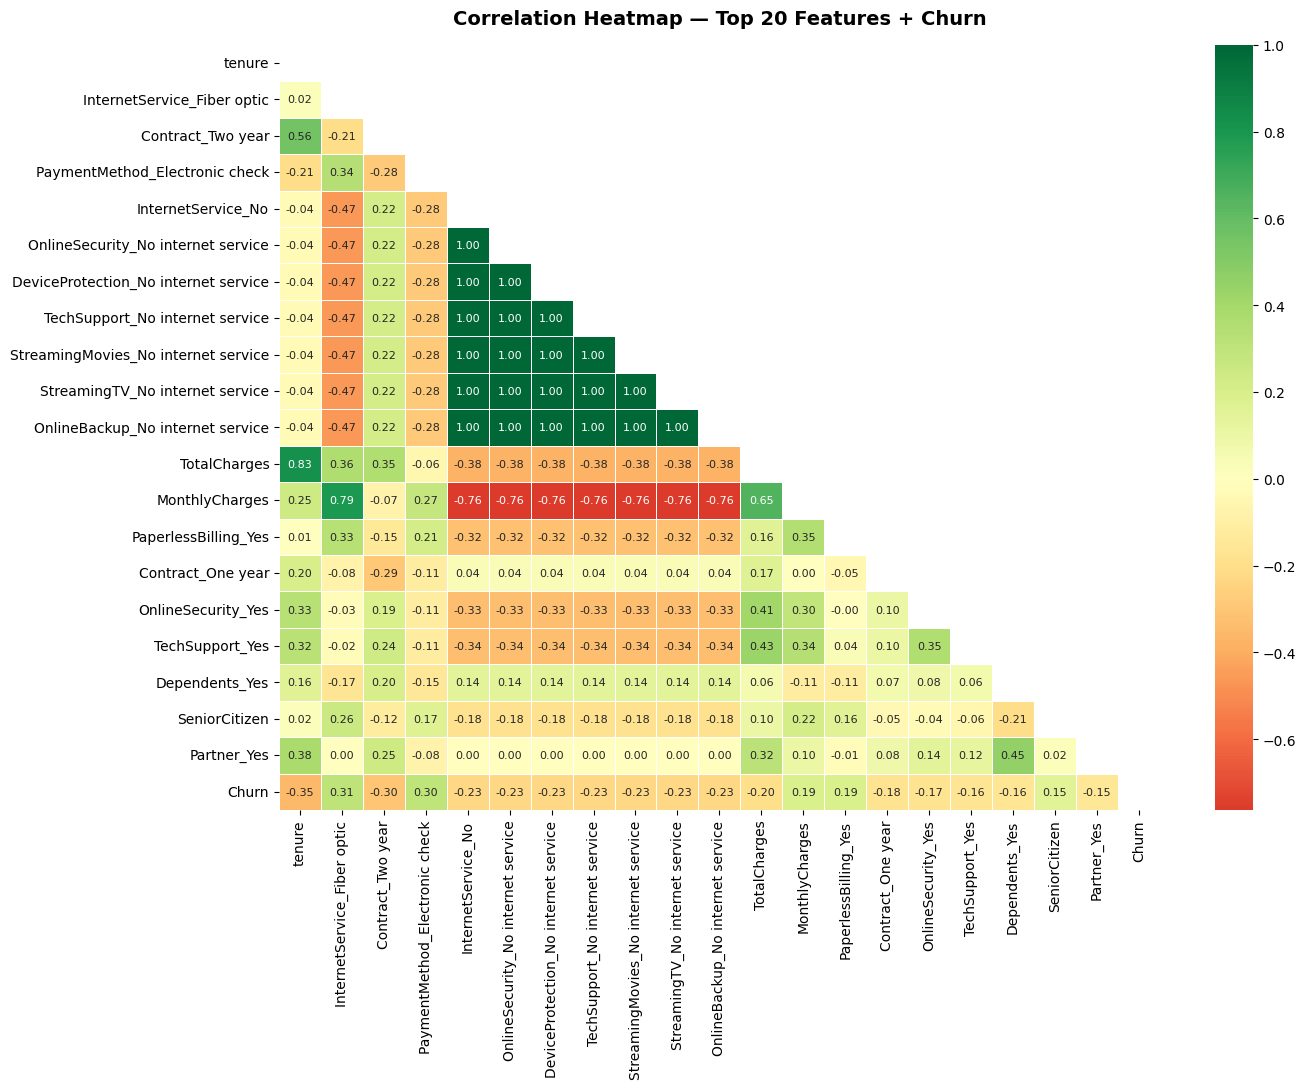

Saved correlation_heatmap.png


In [4]:
# full correlation heatmap for top 20 features + Churn
top_features_for_heatmap = top20_churn_corr.index.tolist() + ['Churn']
corr_subset = df_enc[top_features_for_heatmap].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_subset, dtype=bool))    # upper triangle hidden
sns.heatmap(
    corr_subset, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlation Heatmap — Top 20 Features + Churn', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved correlation_heatmap.png")


## Step 4 - Variance Inflation Factor (VIF)

In [5]:
X_all = df_enc.drop(columns=['Churn'])
y_all = df_enc['Churn']

# scale before VIF to avoid magnitude distortion
scaler_vif = StandardScaler()
X_scaled = pd.DataFrame(scaler_vif.fit_transform(X_all), columns=X_all.columns)

# calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_scaled.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_scaled.values, i)
    for i in range(X_scaled.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("Features with VIF > 5 (multicollinearity concern):")
print(vif_data[vif_data['VIF'] > 5].to_string(index=False))

print(f"\nTotal features with VIF > 10 : {(vif_data['VIF'] > 10).sum()}")
print(f"Total features with VIF > 5  : {(vif_data['VIF'] > 5).sum()}")


Features with VIF > 5 (multicollinearity concern):
                             Feature        VIF
      MultipleLines_No phone service        inf
                    PhoneService_Yes        inf
                  InternetService_No        inf
  OnlineSecurity_No internet service        inf
DeviceProtection_No internet service        inf
    OnlineBackup_No internet service        inf
     TechSupport_No internet service        inf
     StreamingTV_No internet service        inf
 StreamingMovies_No internet service        inf
                      MonthlyCharges 865.062147
         InternetService_Fiber optic 148.263380
                 StreamingMovies_Yes  24.110253
                     StreamingTV_Yes  24.056827
                        TotalCharges  10.793729
                              tenure   7.527280
                   MultipleLines_Yes   7.273906
                DeviceProtection_Yes   6.922434
                    OnlineBackup_Yes   6.782866
                     TechSupport_Yes 

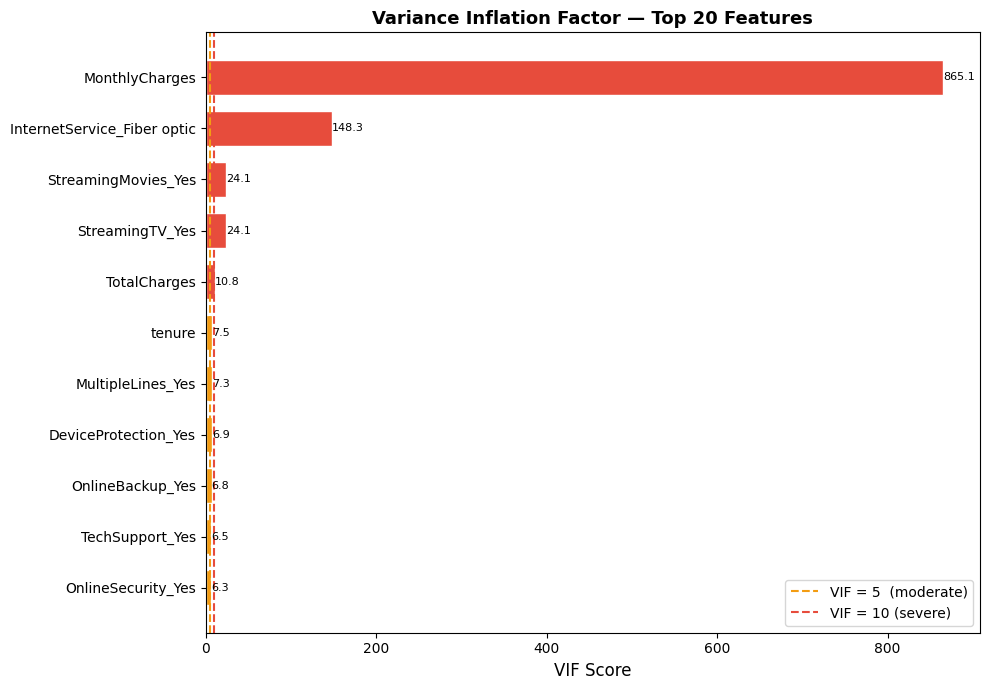

Saved vif_chart.png


In [6]:
# VIF bar chart top 20
vif_top = vif_data.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71' for v in vif_top['VIF']]
bars = ax.barh(vif_top['Feature'], vif_top['VIF'], color=colors, edgecolor='white', height=0.7)
ax.axvline(x=5,  color='#f39c12', linestyle='--', linewidth=1.5, label='VIF = 5  (moderate)')
ax.axvline(x=10, color='#e74c3c', linestyle='--', linewidth=1.5, label='VIF = 10 (severe)')
ax.set_xlabel('VIF Score', fontsize=12)
ax.set_title('Variance Inflation Factor — Top 20 Features', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.invert_yaxis()
for bar, val in zip(bars, vif_top['VIF']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('vif_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved vif_chart.png")


## Step 5 - Univariate Feature Selection (SelectKBest)

In [7]:
# ANOVA F-test
selector_f = SelectKBest(f_classif, k='all')
selector_f.fit(X_scaled, y_all)
f_scores = pd.Series(selector_f.scores_, index=X_scaled.columns)
f_pvals  = pd.Series(selector_f.pvalues_, index=X_scaled.columns)

# Mutual Information
mi_scores = pd.Series(
    mutual_info_classif(X_scaled, y_all, random_state=SEED),
    index=X_scaled.columns
)

# combine results
univariate_df = pd.DataFrame({
    'F_Score'  : f_scores,
    'F_pvalue' : f_pvals,
    'MI_Score' : mi_scores
}).sort_values('MI_Score', ascending=False)

print("Top 20 features by Mutual Information score:")
print(univariate_df.head(20).round(4).to_string())


Top 20 features by Mutual Information score:
                                       F_Score  F_pvalue  MI_Score
tenure                                997.2680       0.0    0.0755
Contract_Two year                     707.9193       0.0    0.0672
InternetService_Fiber optic           738.0460       0.0    0.0538
MonthlyCharges                        273.4637       0.0    0.0496
OnlineSecurity_No internet service    385.6986       0.0    0.0450
TotalCharges                          288.2790       0.0    0.0436
PaymentMethod_Electronic check        706.1950       0.0    0.0436
InternetService_No                    385.6986       0.0    0.0342
StreamingTV_No internet service       385.6986       0.0    0.0338
StreamingMovies_No internet service   385.6986       0.0    0.0325
OnlineBackup_No internet service      385.6986       0.0    0.0307
TechSupport_No internet service       385.6986       0.0    0.0301
DeviceProtection_No internet service  385.6986       0.0    0.0260
Dependents_Yes   

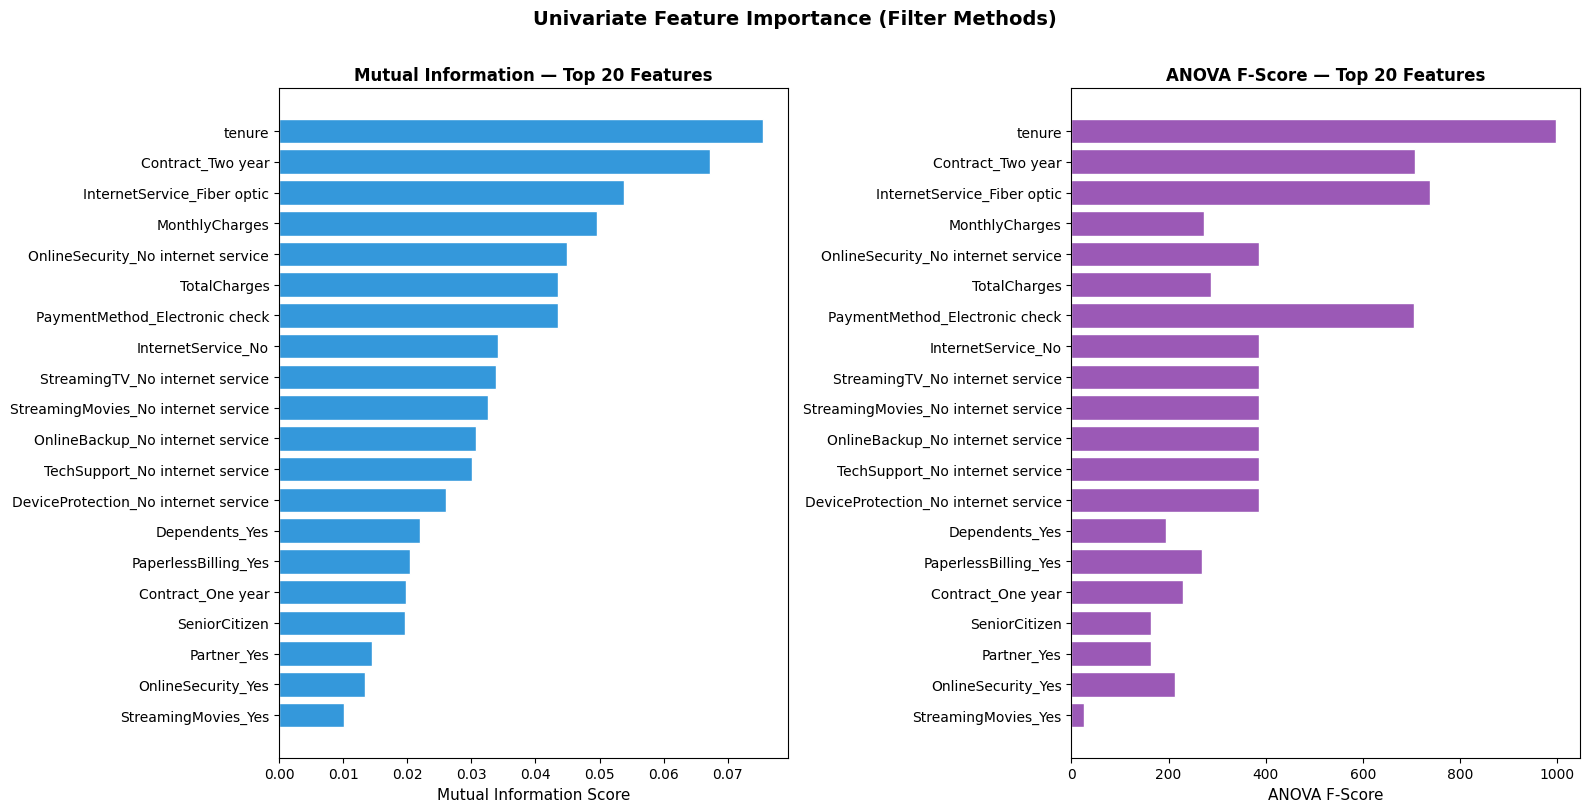

Saved univariate_scores.png


In [8]:
# plot top 20 MI and F scores side by side
top_uni = univariate_df.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Mutual Information
axes[0].barh(top_uni.index, top_uni['MI_Score'], color='#3498db', edgecolor='white')
axes[0].set_xlabel('Mutual Information Score', fontsize=11)
axes[0].set_title('Mutual Information — Top 20 Features', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# F-statistic bar
axes[1].barh(top_uni.index, top_uni['F_Score'], color='#9b59b6', edgecolor='white')
axes[1].set_xlabel('ANOVA F-Score', fontsize=11)
axes[1].set_title('ANOVA F-Score — Top 20 Features', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Univariate Feature Importance (Filter Methods)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved univariate_scores.png")


## Step 6 - Random Forest Feature Importance

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

rf_full = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced', random_state=SEED
)
rf_full.fit(X_train, y_train)

rf_importance = pd.Series(rf_full.feature_importances_, index=X_scaled.columns)
rf_importance = rf_importance.sort_values(ascending=False)

print("Top 20 features by Random Forest importance:")
print(rf_importance.head(20).round(5).to_string())


Top 20 features by Random Forest importance:
tenure                                  0.17900
Contract_Two year                       0.12590
TotalCharges                            0.12484
MonthlyCharges                          0.08176
InternetService_Fiber optic             0.07643
PaymentMethod_Electronic check          0.05840
Contract_One year                       0.04702
OnlineSecurity_Yes                      0.04080
TechSupport_Yes                         0.02667
TechSupport_No internet service         0.02503
DeviceProtection_No internet service    0.02116
StreamingMovies_No internet service     0.01937
OnlineSecurity_No internet service      0.01639
StreamingTV_No internet service         0.01551
PaperlessBilling_Yes                    0.01543
OnlineBackup_No internet service        0.01478
Dependents_Yes                          0.01204
InternetService_No                      0.01139
OnlineBackup_Yes                        0.01106
Partner_Yes                             0.0

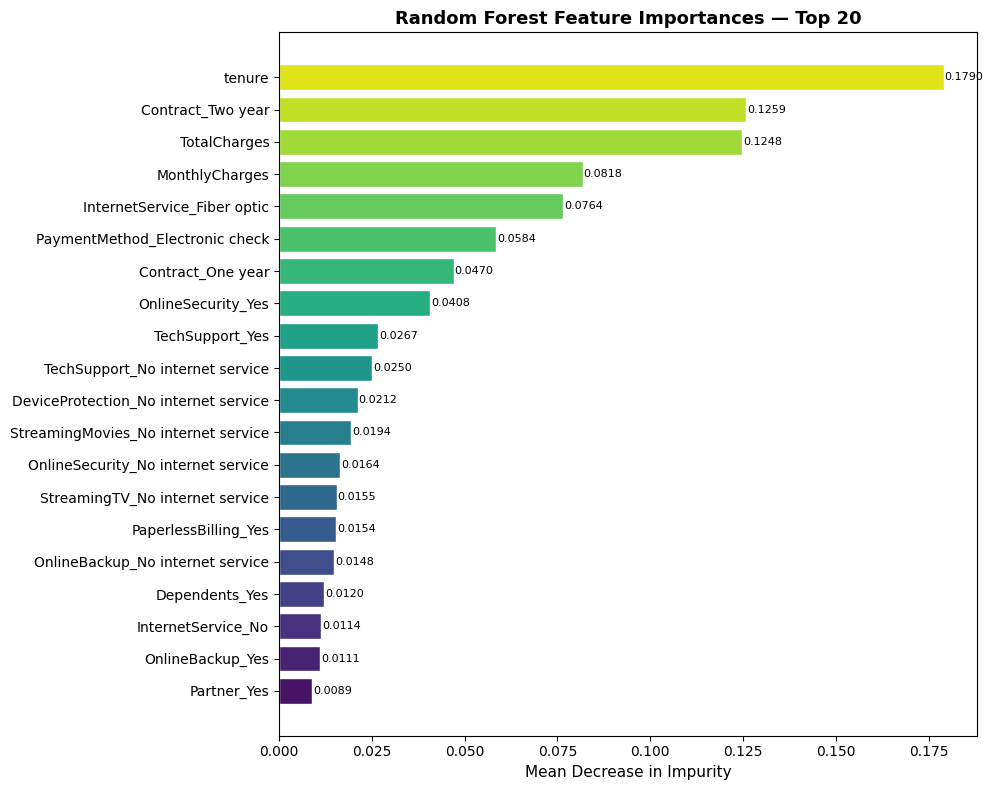

Saved rf_importance.png


In [10]:
# RF importance bar chart
rf_top20 = rf_importance.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette('viridis', 20)
ax.barh(rf_top20.index[::-1], rf_top20.values[::-1], color=palette, edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax.set_title('Random Forest Feature Importances — Top 20', fontsize=13, fontweight='bold')
for i, (val, name) in enumerate(zip(rf_top20.values[::-1], rf_top20.index[::-1])):
    ax.text(val + 0.0003, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved rf_importance.png")


## Step 7 - Recursive Feature Elimination (RFE)

In [11]:
lr_for_rfe = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED)
rfe = RFE(estimator=lr_for_rfe, n_features_to_select=15, step=1)
rfe.fit(X_train, y_train)

rfe_df = pd.DataFrame({
    'Feature'  : X_scaled.columns,
    'Selected' : rfe.support_,
    'Rank'     : rfe.ranking_
}).sort_values('Rank')

print("RFE selected features (rank = 1 means selected):")
print(rfe_df[rfe_df['Selected']].to_string(index=False))


RFE selected features (rank = 1 means selected):
                            Feature  Selected  Rank
                             tenure      True     1
                     MonthlyCharges      True     1
                       TotalCharges      True     1
                  MultipleLines_Yes      True     1
        InternetService_Fiber optic      True     1
   OnlineBackup_No internet service      True     1
StreamingMovies_No internet service      True     1
     PaymentMethod_Electronic check      True     1
                  Contract_One year      True     1
                  Contract_Two year      True     1
               PaperlessBilling_Yes      True     1
                StreamingMovies_Yes      True     1
    StreamingTV_No internet service      True     1
                    StreamingTV_Yes      True     1
    TechSupport_No internet service      True     1


## Step 8 - Consensus Feature Ranking

In [12]:
# normalize each score to 0 to 1
def normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return (series - mn) / (mx - mn)

mi_norm  = normalize(univariate_df['MI_Score'])
f_norm   = normalize(univariate_df['F_Score'])
rf_norm  = normalize(rf_importance)
# rfe: invert rank so rank 1 gets highest score
rfe_score = 1 / rfe_df.set_index('Feature')['Rank']
rfe_norm  = normalize(rfe_score)

consensus = pd.DataFrame({
    'MI_norm'  : mi_norm,
    'F_norm'   : f_norm,
    'RF_norm'  : rf_norm,
    'RFE_norm' : rfe_norm
}).fillna(0)

consensus['Consensus_Score'] = consensus.mean(axis=1)
consensus = consensus.sort_values('Consensus_Score', ascending=False)

print("Top 20 features by Consensus Score:")
print(consensus.head(20).round(4).to_string())


Top 20 features by Consensus Score:
                                      MI_norm  F_norm  RF_norm  RFE_norm  Consensus_Score
tenure                                 1.0000  1.0000   1.0000    1.0000           1.0000
Contract_Two year                      0.8900  0.7097   0.6986    1.0000           0.8246
InternetService_Fiber optic            0.7127  0.7399   0.4178    1.0000           0.7176
PaymentMethod_Electronic check         0.5769  0.7080   0.3155    1.0000           0.6501
TotalCharges                           0.5771  0.2887   0.6926    1.0000           0.6396
MonthlyCharges                         0.6569  0.2738   0.4481    1.0000           0.5947
StreamingMovies_No internet service    0.4307  0.3864   0.0940    1.0000           0.4778
TechSupport_No internet service        0.3982  0.3864   0.1261    1.0000           0.4777
StreamingTV_No internet service        0.4478  0.3864   0.0721    1.0000           0.4766
OnlineBackup_No internet service       0.4070  0.3864   0.0680  

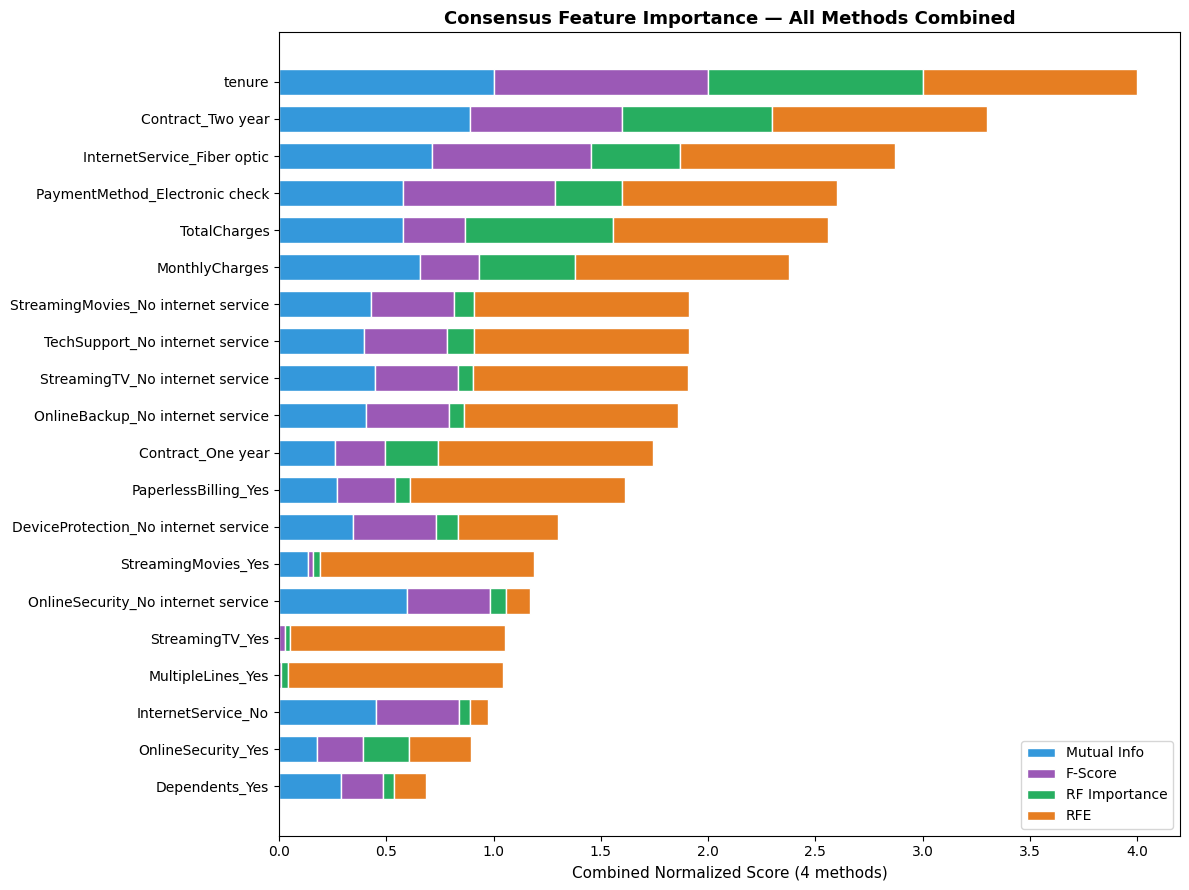

Saved consensus_importance.png


In [13]:
# stacked bar chart of method scores
top_consensus = consensus.head(20)

fig, ax = plt.subplots(figsize=(12, 9))
colors_stack = ['#3498db', '#9b59b6', '#27ae60', '#e67e22']
labels_stack = ['Mutual Info', 'F-Score', 'RF Importance', 'RFE']

bottom = np.zeros(len(top_consensus))
for col, color, label in zip(['MI_norm', 'F_norm', 'RF_norm', 'RFE_norm'], colors_stack, labels_stack):
    ax.barh(top_consensus.index, top_consensus[col], left=bottom,
            color=color, label=label, edgecolor='white', height=0.7)
    bottom += top_consensus[col].values

ax.set_xlabel('Combined Normalized Score (4 methods)', fontsize=11)
ax.set_title('Consensus Feature Importance — All Methods Combined', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('consensus_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved consensus_importance.png")


## Step 9 - Select Final Feature Set

In [14]:
N_SELECT = 15
selected_features = consensus.head(N_SELECT).index.tolist()

print(f"Selected top {N_SELECT} features:")
for i, feat in enumerate(selected_features, 1):
    vif_val = vif_data.set_index('Feature')['VIF'].get(feat, float('nan'))
    score   = consensus.loc[feat, 'Consensus_Score']
    print(f"  {i:2d}. {feat:<45s}  consensus={score:.4f}  VIF={vif_val:.2f}")

# check for high VIF in selected set
high_vif_selected = [
    f for f in selected_features
    if vif_data.set_index('Feature')['VIF'].get(f, 0) > 10
]
if high_vif_selected:
    print(f"\nHigh VIF (>10) in selected set: {high_vif_selected}")
    print("   These are flagged but kept since their predictive power is confirmed by other methods.")
else:
    print("\nNo features with VIF > 10 in the selected set.")


Selected top 15 features:
   1. tenure                                         consensus=1.0000  VIF=7.53
   2. Contract_Two year                              consensus=0.8246  VIF=2.63
   3. InternetService_Fiber optic                    consensus=0.7176  VIF=148.26
   4. PaymentMethod_Electronic check                 consensus=0.6501  VIF=1.98
   5. TotalCharges                                   consensus=0.6396  VIF=10.79
   6. MonthlyCharges                                 consensus=0.5947  VIF=865.06
   7. StreamingMovies_No internet service            consensus=0.4778  VIF=inf
   8. TechSupport_No internet service                consensus=0.4777  VIF=inf
   9. StreamingTV_No internet service                consensus=0.4766  VIF=inf
  10. OnlineBackup_No internet service               consensus=0.4653  VIF=inf
  11. Contract_One year                              consensus=0.4358  VIF=1.62
  12. PaperlessBilling_Yes                           consensus=0.4028  VIF=1.21
  13. DeviceP

## Step 10 - Before vs After Comparison

In [15]:
X_full     = X_scaled.copy()
X_selected = X_scaled[selected_features].copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'LogisticRegression'   : LogisticRegression(max_iter=1000, random_state=SEED),
    'RandomForest'         : RandomForestClassifier(n_estimators=200, max_depth=8,
                                                     class_weight='balanced', random_state=SEED),
    'GradientBoosting'     : GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                         random_state=SEED),
}

results = []
for name, model in models.items():
    for label, X in [('All Features', X_full), ('Selected Features', X_selected)]:
        scores = cross_val_score(model, X, y_all, cv=cv, scoring='roc_auc')
        results.append({
            'Model'       : name,
            'Feature Set' : label,
            'ROC-AUC Mean': scores.mean(),
            'ROC-AUC Std' : scores.std(),
        })

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))


             Model       Feature Set  ROC-AUC Mean  ROC-AUC Std
LogisticRegression      All Features        0.8451       0.0133
LogisticRegression Selected Features        0.8410       0.0126
      RandomForest      All Features        0.8457       0.0129
      RandomForest Selected Features        0.8434       0.0115
  GradientBoosting      All Features        0.8396       0.0099
  GradientBoosting Selected Features        0.8349       0.0112


In [16]:
# single split metrics for detailed comparison
X_tr_full, X_te_full, y_tr, y_te = train_test_split(
    X_full, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_tr_sel = X_tr_full[selected_features]
X_te_sel = X_te_full[selected_features]

detailed = []
for name, model in models.items():
    for label, Xtr, Xte in [
        ('All Features',      X_tr_full, X_te_full),
        ('Selected Features', X_tr_sel,  X_te_sel),
    ]:
        m = type(model)(**model.get_params())  # fresh instance each loop
        m.fit(Xtr, y_tr)
        yp = m.predict(Xte)
        yp_proba = m.predict_proba(Xte)[:, 1]
        detailed.append({
            'Model'       : name,
            'Feature Set' : label,
            'Accuracy'    : accuracy_score(y_te, yp),
            'Precision'   : precision_score(y_te, yp, zero_division=0),
            'Recall'      : recall_score(y_te, yp),
            'F1'          : f1_score(y_te, yp, zero_division=0),
            'ROC-AUC'     : roc_auc_score(y_te, yp_proba),
        })

detailed_df = pd.DataFrame(detailed)
print(detailed_df.round(4).to_string(index=False))


             Model       Feature Set  Accuracy  Precision  Recall     F1  ROC-AUC
LogisticRegression      All Features    0.8070     0.6594  0.5642 0.6081   0.8419
LogisticRegression Selected Features    0.7899     0.6242  0.5241 0.5698   0.8368
      RandomForest      All Features    0.7630     0.5366  0.7834 0.6370   0.8433
      RandomForest Selected Features    0.7573     0.5296  0.7647 0.6258   0.8415
  GradientBoosting      All Features    0.7999     0.6465  0.5428 0.5901   0.8378
  GradientBoosting Selected Features    0.7956     0.6433  0.5160 0.5727   0.8375


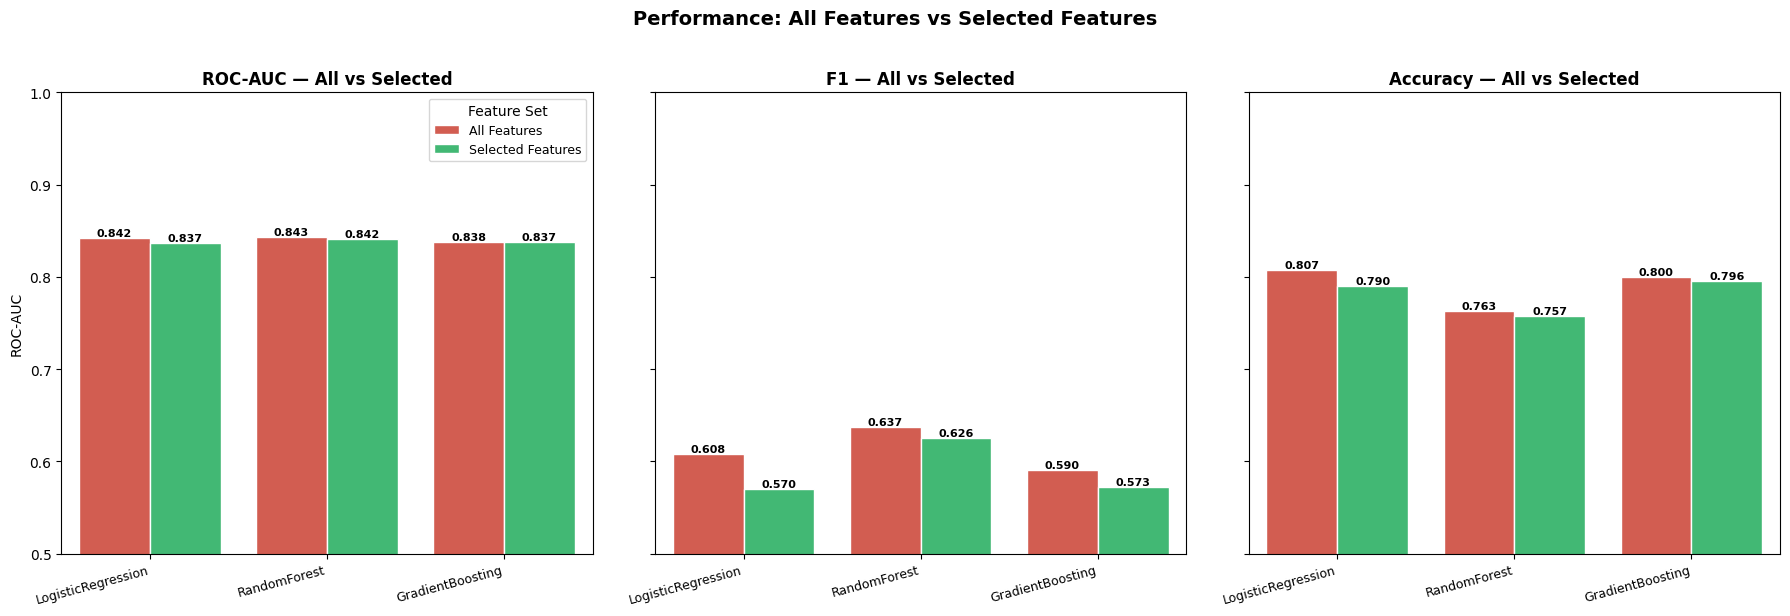

Saved before_after_comparison.png


In [17]:
# comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics_to_plot = ['ROC-AUC', 'F1', 'Accuracy']
palette = {'All Features': '#e74c3c', 'Selected Features': '#2ecc71'}

for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(
        data=detailed_df, x='Model', y=metric, hue='Feature Set',
        ax=ax, palette=palette, edgecolor='white'
    )
    ax.set_title(f'{metric} — All vs Selected', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylim(0.5, 1.0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
    for p in ax.patches:
        h = p.get_height()
        if h > 0.5:
            ax.annotate(f'{h:.3f}', (p.get_x() + p.get_width()/2, h),
                        ha='center', va='bottom', fontsize=8, fontweight='bold')
    if ax != axes[0]:
        ax.get_legend().remove()

axes[0].legend(title='Feature Set', fontsize=9)
plt.suptitle('Performance: All Features vs Selected Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved before_after_comparison.png")


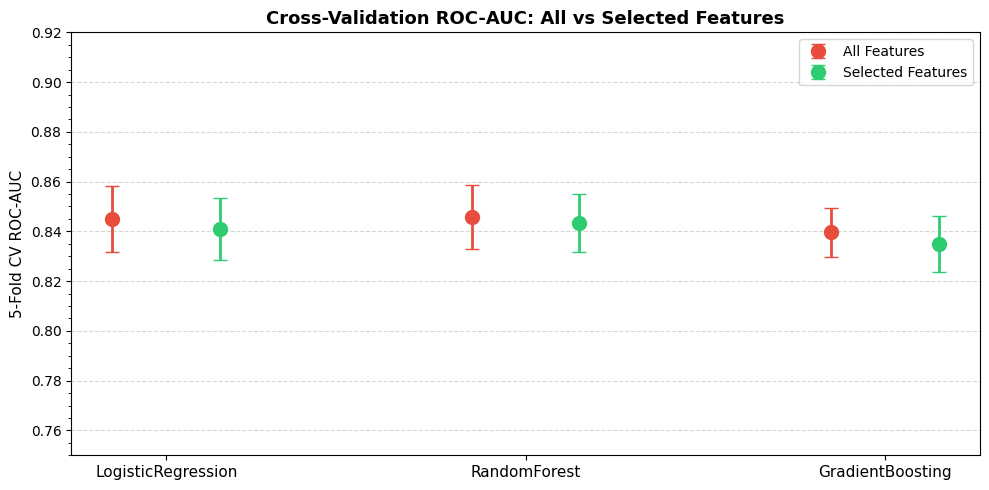

Saved cv_comparison.png


In [18]:
# cross-val comparison dot plot
fig, ax = plt.subplots(figsize=(10, 5))

palette_cv = {'All Features': '#e74c3c', 'Selected Features': '#2ecc71'}
x_labels = results_df['Model'].unique()
x_pos = {m: i for i, m in enumerate(x_labels)}
offset = {'All Features': -0.15, 'Selected Features': 0.15}

for _, row in results_df.iterrows():
    xp = x_pos[row['Model']] + offset[row['Feature Set']]
    color = palette_cv[row['Feature Set']]
    ax.errorbar(xp, row['ROC-AUC Mean'], yerr=row['ROC-AUC Std'],
                fmt='o', color=color, markersize=10, capsize=5, linewidth=2,
                label=row['Feature Set'])

# remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=11)
ax.set_ylabel('5-Fold CV ROC-AUC', fontsize=11)
ax.set_ylim(0.75, 0.92)
ax.set_title('Cross-Validation ROC-AUC: All vs Selected Features', fontsize=13, fontweight='bold')
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved cv_comparison.png")


## Step 11 - Save Selected Features

In [19]:
# save consensus ranking table
consensus.reset_index().rename(columns={'index': 'Feature'}).to_csv(
    'feature_ranking.csv', index=False
)
print("Saved feature_ranking.csv")

# save the selected feature list
with open('selected_features.txt', 'w') as f:
    f.write('\n'.join(selected_features))
print(f"Saved selected_features.txt  ({len(selected_features)} features)")

# print final selected set
print("\nFinal Selected Features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")


Saved feature_ranking.csv
Saved selected_features.txt  (15 features)

Final Selected Features:
   1. tenure
   2. Contract_Two year
   3. InternetService_Fiber optic
   4. PaymentMethod_Electronic check
   5. TotalCharges
   6. MonthlyCharges
   7. StreamingMovies_No internet service
   8. TechSupport_No internet service
   9. StreamingTV_No internet service
  10. OnlineBackup_No internet service
  11. Contract_One year
  12. PaperlessBilling_Yes
  13. DeviceProtection_No internet service
  14. StreamingMovies_Yes
  15. OnlineSecurity_No internet service


## Step 12 - Summary